In [ ]:
import kagglehub

path_fruits = kagglehub.dataset_download('moltean/fruits')
print('Dataset root:', path_fruits)

Using Colab cache for faster access to the 'fruits' dataset.
Dataset root: /kaggle/input/fruits


In [ ]:
import os
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib import transforms
import seaborn as sns
from PIL import Image

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import Callback, EarlyStopping

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Build the specific paths to the training and test folders
train_dir = os.path.join(path_fruits, "fruits-360_100x100", "fruits-360", "Training")
test_dir = os.path.join(path_fruits, "fruits-360_100x100", "fruits-360", "Test")

print("---")
print("Train Directory:", train_dir)
print("Test Directory:", test_dir)

# Quick check to ensure the script sees them
if os.path.exists(train_dir) and os.path.exists(test_dir):
    print("\n Success! Folders found and separated.")
    print(f"Total training classes (fruits): {len(os.listdir(train_dir))}")
    print(f"Total test classes (fruits): {len(os.listdir(test_dir))}")
else:
    print("\n Paths built, but directories not found. Check the exact folder names inside:", os.listdir(os.path.join(path, "fruits-360_100x100")))

---
Train Directory: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
Test Directory: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Test

 Success! Folders found and separated.
Total training classes (fruits): 260
Total test classes (fruits): 260


In [ ]:
classes = sorted([c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))])
total_classes = len(classes)

print(f"Total number of classes detected: {total_classes}")

# CALCULATE CLASS DISTRIBUTION
class_counts = {}
for c in classes:
    class_path = os.path.join(train_dir, c)
    class_counts[c] = len(os.listdir(class_path))

max_img = max(class_counts.values())
min_img = min(class_counts.values())
print(f"Class with the most images has: {max_img}")
print(f"Class with the fewest images has: {min_img}")
print(f"Are they completely balanced? {'Yes' if max_img == min_img else 'No, there is some variance.'}")

Total number of classes detected: 260
Class with the most images has: 984
Class with the fewest images has: 144
Are they completely balanced? No, there is some variance.


/tmp/ipykernel_2441/4204216626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=first_40_classes, y=first_40_counts, palette="viridis")


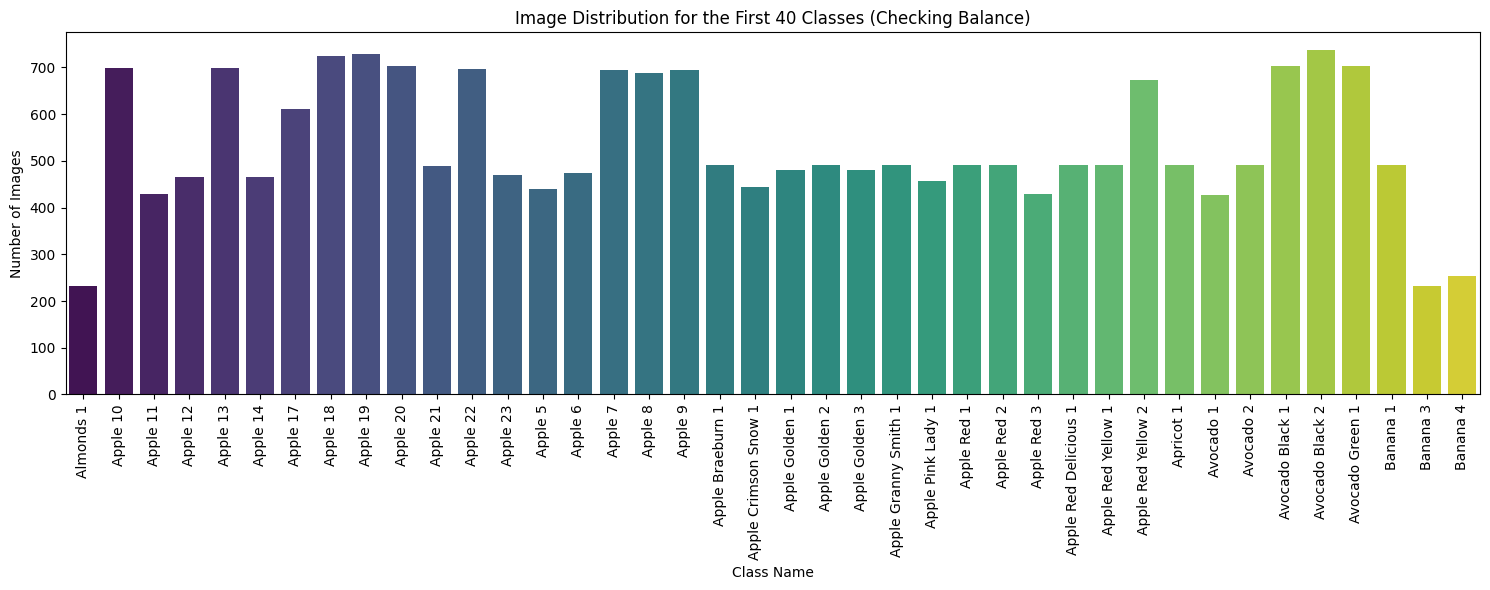

In [ ]:
# PLOT DISTRIBUTION (First 40 Classes)
first_40_classes = classes[:40]
first_40_counts = [class_counts[c] for c in first_40_classes]

plt.figure(figsize=(15, 6))
sns.barplot(x=first_40_classes, y=first_40_counts, palette="viridis")
plt.xticks(rotation=90)
plt.title("Image Distribution for the First 40 Classes (Checking Balance)")
plt.ylabel("Number of Images")
plt.xlabel("Class Name")
plt.tight_layout()
plt.show()

Sample Image Properties -> Format: JPEG | Size: (100, 100) | Mode: RGB


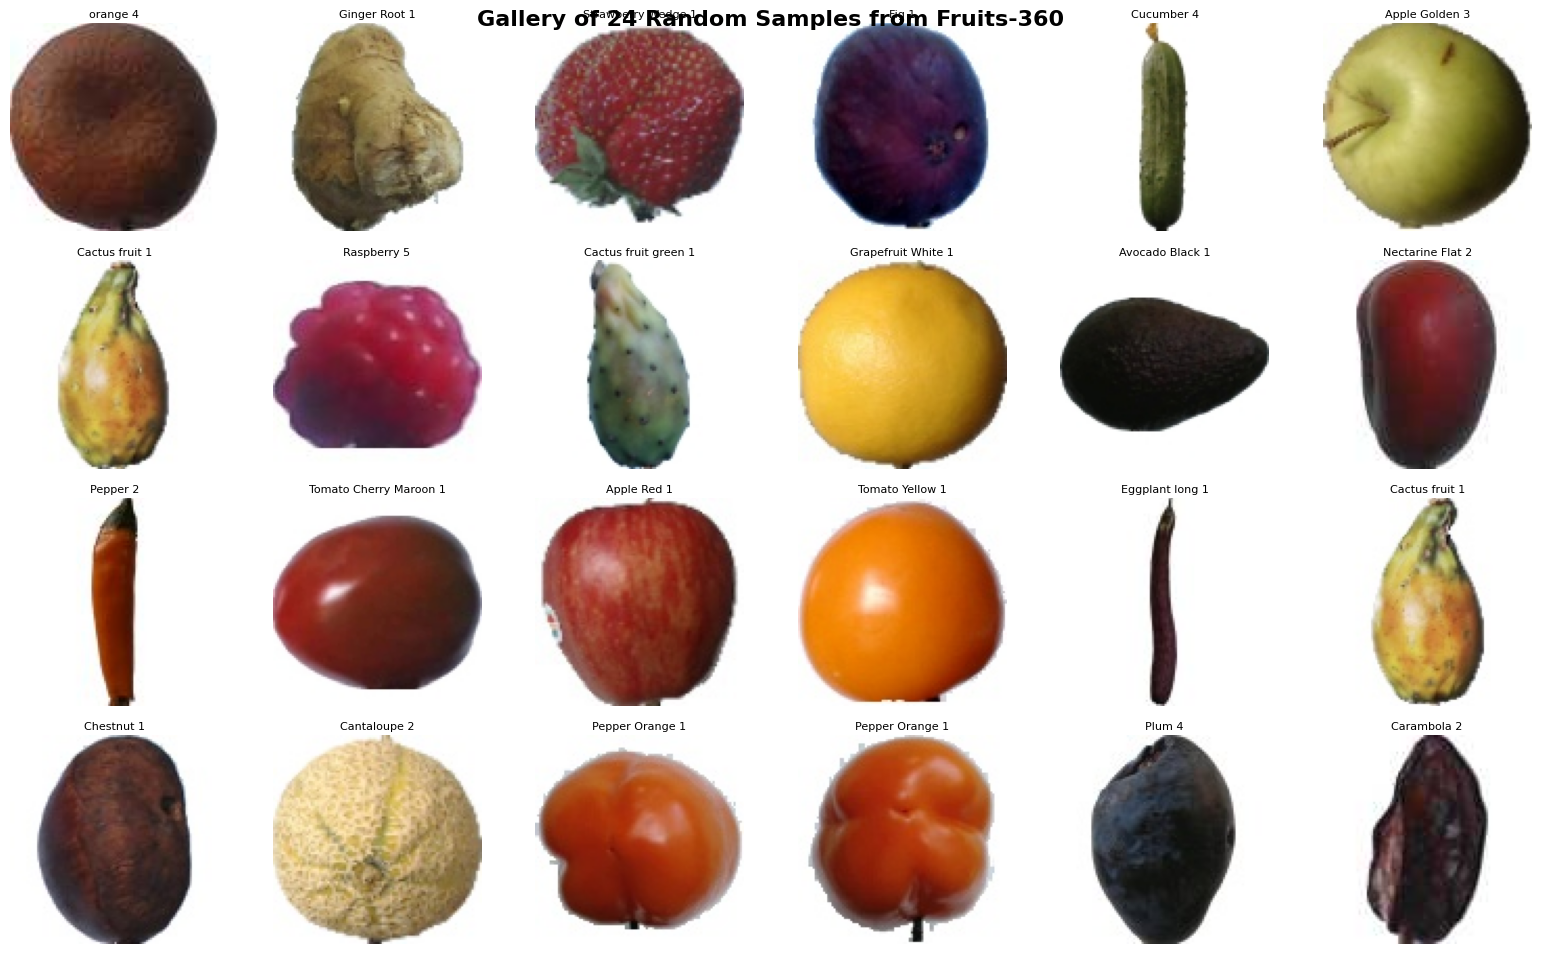

In [ ]:
ROWS = 4
COLS = 6
num_samples = ROWS * COLS

plt.figure(figsize=(16, 10))

for i in range(num_samples):
    # Pick a random class and a random image from that class
    random_class = random.choice(classes)
    class_path = os.path.join(train_dir, random_class)
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)

    if i == 0:
        print(f"Sample Image Properties -> Format: {img.format} | Size: {img.size} | Mode: {img.mode}")

    plt.subplot(ROWS, COLS, i + 1)
    plt.imshow(img)
    plt.title(random_class, fontsize=8, pad=4)
    plt.axis("off")

plt.suptitle(f"Gallery of {num_samples} Random Samples from Fruits-360", fontsize=16, weight='bold', y=0.95)
plt.tight_layout()
plt.show()

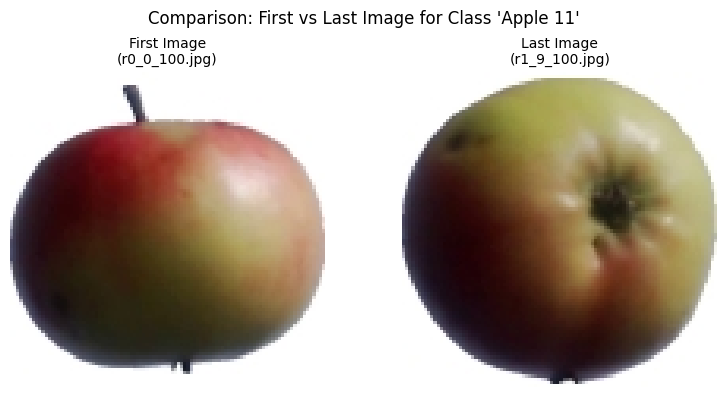

In [ ]:
#COMPARE FIRST AND LAST IMAGE OF A CLASS
target_class = classes[2]
class_path = os.path.join(train_dir, target_class)
all_images = sorted([img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])

if len(all_images) >= 2:
    first_img_path = os.path.join(class_path, all_images[0])
    last_img_path = os.path.join(class_path, all_images[-1])

    img_first = Image.open(first_img_path)
    img_last = Image.open(last_img_path)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_first)
    axes[0].set_title(f"First Image\n({all_images[0]})", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(img_last)
    axes[1].set_title(f"Last Image\n({all_images[-1]})", fontsize=10)
    axes[1].axis("off")

    plt.suptitle(f"Comparison: First vs Last Image for Class '{target_class}'", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"Not enough images in class '{target_class}' to perform first/last comparison.")

In [ ]:

# Load Train and Validation Sets (Handles 80/20 split, resize, and shuffle)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,                  # Seed ensures train/val sets don't overlap
    image_size=(48, 48),      # Resizes images to 48x48
    batch_size=32,
    shuffle=True              # Shuffles the training data
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,                  # Must match training seed!
    image_size=(48, 48),
    batch_size=32,
    shuffle=True              # Shuffles validation data as well
)

# Rescale images from [0, 255] to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("\nTensorFlow datasets are ready!")

Found 137221 files belonging to 260 classes.
Using 109777 files for training.
Found 137221 files belonging to 260 classes.
Using 27444 files for validation.

TensorFlow datasets are ready!


TensorFlow Pipeline Verified:
Batch Shape: [32, 48, 48, 3]
Pixel Range: [0.0000, 1.0000]


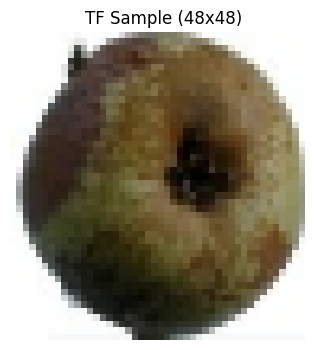

In [ ]:
# VERIFY TENSORFLOW PIPELINE
for tf_images, tf_labels in train_ds.take(1):
    tf_batch_shape = tf_images.shape
    tf_min_val = tf.reduce_min(tf_images).numpy()
    tf_max_val = tf.reduce_max(tf_images).numpy()
    single_tf_img = tf_images[0].numpy()
    break

print(f"TensorFlow Pipeline Verified:")
print(f"Batch Shape: {list(tf_batch_shape)}")
print(f"Pixel Range: [{tf_min_val:.4f}, {tf_max_val:.4f}]")

plt.figure(figsize=(4, 4))
plt.imshow(single_tf_img)
plt.title(f"TF Sample (48x48)")
plt.axis('off')
plt.show()

In [ ]:


# CUSTOM TIMING CALLBACK
class EpochTimer(Callback):
    """Custom callback to measure and print the duration of each epoch."""
    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.start_time
        print(f" - Epoch time: {duration:.2f} seconds")



In [ ]:
# 2. CNN CONFIGURATOR
def build_cnn(
    num_classes,
    filters=(32, 64, 128),
    kernel_size=3,
    strides=1,
    padding='same',
    pool='max',
    dropout_rate=0.0,
    l2_reg=0.0,
    input_shape=(48, 48, 3),
    augment_pipeline=None
):
    """Configurable CNN builder for systematic experiments."""
    pool_layer = layers.MaxPooling2D if pool == 'max' else layers.AveragePooling2D
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    model = keras.Sequential(name='CNN')
    model.add(layers.Input(shape=input_shape))

    for f in filters:
        model.add(layers.Conv2D(f, kernel_size, strides=strides,
                                padding=padding, activation='relu',
                                kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(pool_layer(2))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=reg))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model



In [ ]:
# TRAINING ENGINE

def train_model(model, train_ds, val_ds, epochs=15, callbacks=None,
                verbose=1, early_stop=True, patience=3):
    """Compile, fit, and return history. Adds EarlyStopping unless one is already passed."""
    cbs = list(callbacks) if callbacks else []

    if early_stop and not any(isinstance(c, EarlyStopping) for c in cbs):
        cbs.append(EarlyStopping(monitor='val_accuracy', patience=patience,
                                 restore_best_weights=True, verbose=1))
    cbs.append(EpochTimer())

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=cbs,
        verbose=verbose
    )
    return history

In [ ]:


# Look directly inside the training folder to count the actual class directories
detected_classes = [c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))]
num_detected_classes = len(detected_classes)

print(f"Dynamically detected {num_detected_classes} classes in directory.")

baseline_model = build_cnn(
    num_classes=num_detected_classes,
    filters=(32, 64, 128),
    input_shape=(48, 48, 3)
)

history_baseline = train_model(
    model=baseline_model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=10
)

Dynamically detected 260 classes in directory.
Epoch 1/10
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7132 - loss: 1.2561 - Epoch time: 232.80 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 233s 66ms/step - accuracy: 0.8751 - loss: 0.4744 - val_accuracy: 0.9628 - val_loss: 0.1703
Epoch 2/10
3427/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9679 - loss: 0.1050 - Epoch time: 63.95 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 64s 19ms/step - accuracy: 0.9707 - loss: 0.0991 - val_accuracy: 0.9683 - val_loss: 0.1191
Epoch 3/10
3427/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9814 - loss: 0.0633 - Epoch time: 63.78 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 64s 19ms/step - accuracy: 0.9816 - loss: 0.0661 - val_accuracy: 0.9691 - val_loss: 0.1259
Epoch 4/10
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9867 - loss: 0.0505 - Epoch time: 64.22 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 64s 19ms/step - accuracy: 0.9874 - loss: 0.0466 - val_accuracy: 0.9926 - val_loss: 0.0266

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
baseline_model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,021,710 (15.34 MB)

 Trainable params: 1,340,420 (5.11 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2,680,842 (10.23 MB)

In [ ]:


#Configuration Constants
SEED = 42
EXPERIMENT_EPOCHS = 5  # 10 epochs per test is a great sweet spot but 5 is better for testing
results = []

# Systematic architecture configurations
experiments = [
    dict(name='Baseline',           filters=(32,64,128), strides=1, padding='same', pool='max'),
    dict(name='Fewer filters',      filters=(16,32,64),  strides=1, padding='same', pool='max'),
    dict(name='AvgPool',            filters=(32,64,128), strides=1, padding='same', pool='avg'),
    dict(name='Stride=2 (no pool)', filters=(32,64,128), strides=2, padding='same', pool='none')
]


# Execution Loop
for i, exp_orig in enumerate(experiments, 1):
    exp = exp_orig.copy()
    name = exp.pop('name')

    print(f'\n>>> [{i}/{len(experiments)}] Training: {name}', flush=True)
    tf.random.set_seed(SEED)

    if exp['pool'] == 'none':
        exp['pool'] = 'max'
        exp['filters'] = (32, 64)

    m = build_cnn(num_classes=num_detected_classes, input_shape=(48, 48, 3), **exp)
    h = train_model(m, train_ds, val_ds, epochs=EXPERIMENT_EPOCHS, verbose=0)

    # Extract results
    best_val = max(h.history['val_accuracy'])
    results.append({
        'Experiment': name,
        'Filters': str(exp_orig['filters']), # Keeping original description for the table
        'Strides': exp_orig['strides'],
        'Padding': exp_orig['padding'],
        'Pool': exp_orig['pool'],
        'Val Accuracy': round(best_val, 4)
    })
    print(f'   >>> [{name}] best_val_acc={best_val:.4f}', flush=True)

# Display Results Table sorted by best performance
results_df = pd.DataFrame(results).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
print('\n=== Architecture Experiments ===')
print(results_df.to_string(index=False))


>>> [1/4] Training: Baseline
 - Epoch time: 76.86 seconds
 - Epoch time: 63.58 seconds
 - Epoch time: 62.96 seconds
 - Epoch time: 62.51 seconds
 - Epoch time: 62.44 seconds
Restoring model weights from the end of the best epoch: 4.
   >>> [Baseline] best_val_acc=0.9893

>>> [2/4] Training: Fewer filters
 - Epoch time: 80.56 seconds
 - Epoch time: 64.36 seconds
 - Epoch time: 62.37 seconds
 - Epoch time: 61.79 seconds
 - Epoch time: 63.04 seconds
Restoring model weights from the end of the best epoch: 5.
   >>> [Fewer filters] best_val_acc=0.9576

>>> [3/4] Training: AvgPool
 - Epoch time: 73.92 seconds
 - Epoch time: 73.80 seconds
 - Epoch time: 62.08 seconds
 - Epoch time: 62.24 seconds
 - Epoch time: 61.66 seconds
Restoring model weights from the end of the best epoch: 5.
   >>> [AvgPool] best_val_acc=0.9872

>>> [4/4] Training: Stride=2 (no pool)
 - Epoch time: 66.71 seconds
 - Epoch time: 78.63 seconds
 - Epoch time: 60.29 seconds
 - Epoch time: 82.74 seconds
 - Epoch time: 60.36

Rebuilding best architecture configuration discovered:
 -> Filters: (32, 64, 128) | Strides: 2 | Padding: same | Pool: none



Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 12, 12, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 3, 3, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 1, 1, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,988 (757.77 KB)

 Trainable params: 193,540 (756.02 KB)

 Non-trainable params: 448 (1.75 KB)

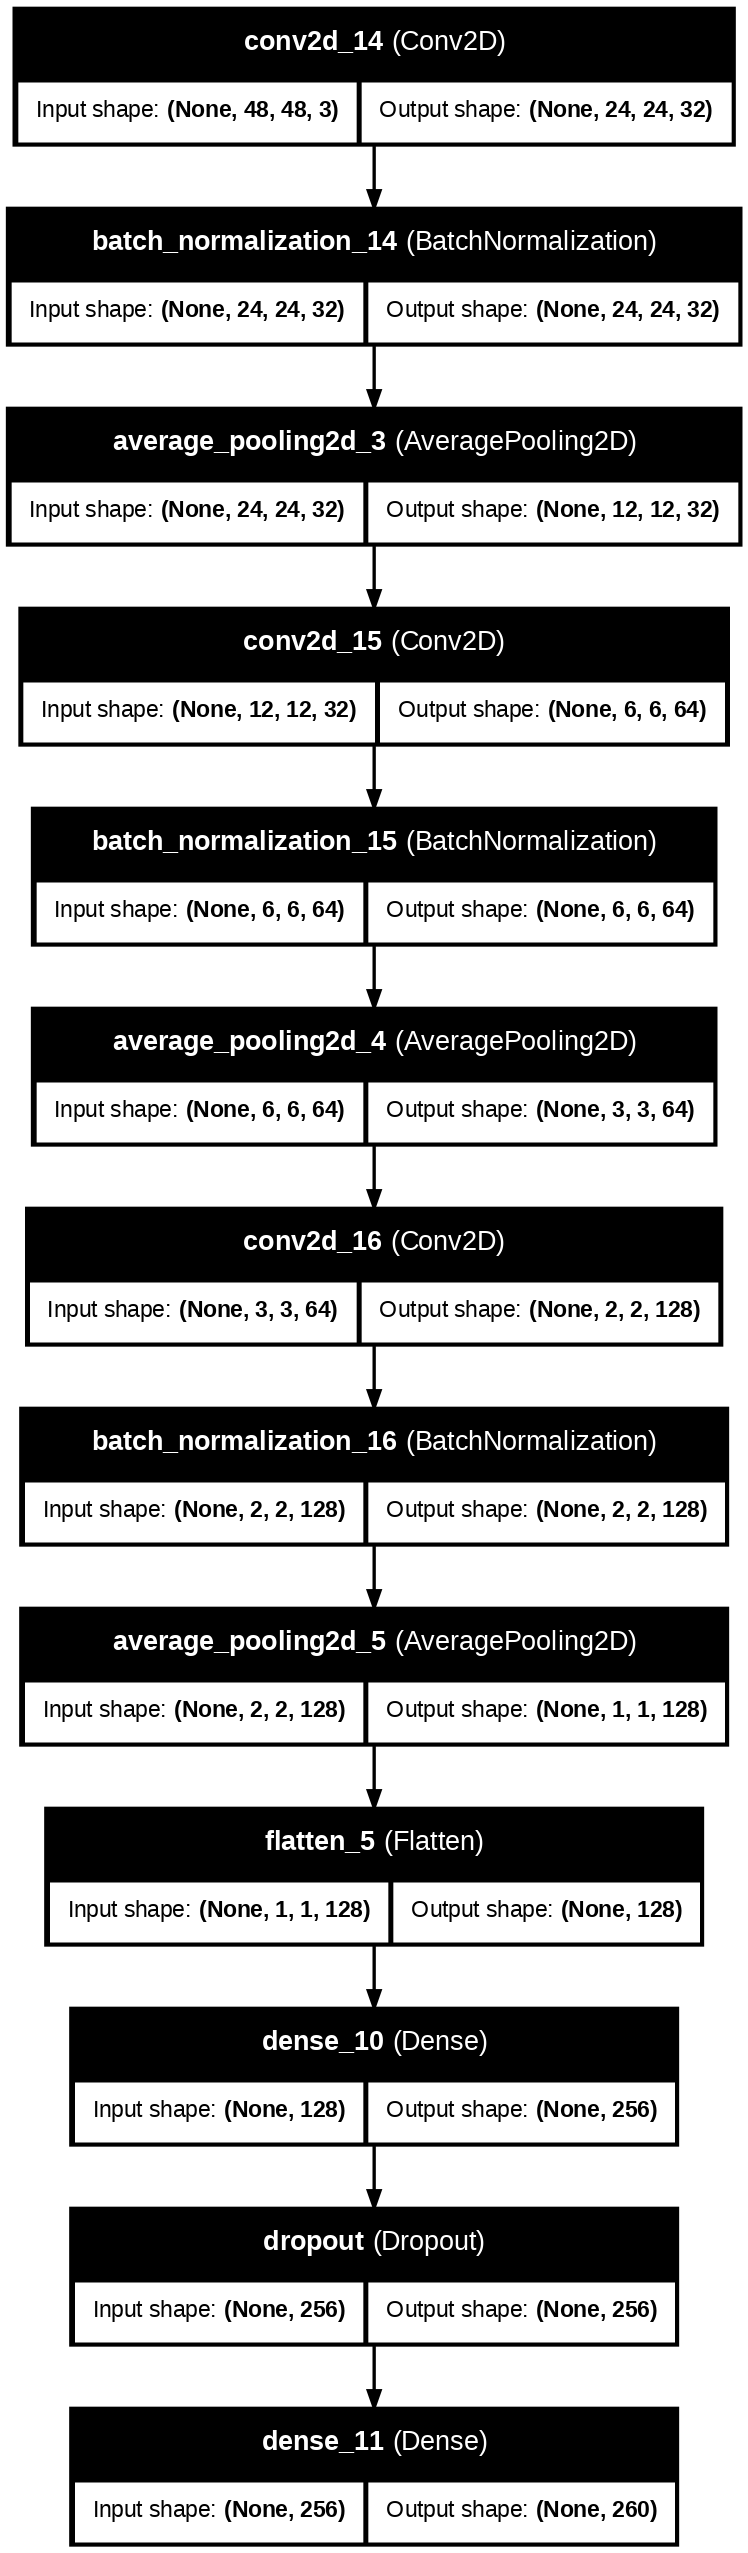

Success! Corrected 48x48 diagram rendered above.


In [ ]:
# Ensure directory for figures exists
import ast


FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Extract configurations dynamically from the top row of the results DataFrame
best_filters = tuple(ast.literal_eval(results_df.iloc[0]['Filters']))
best_padding = str(results_df.iloc[0]['Padding'])
best_pool    = str(results_df.iloc[0]['Pool'])
best_strides = int(results_df.iloc[0]['Strides'])

print(f"Rebuilding best architecture configuration discovered:")
print(f" -> Filters: {best_filters} | Strides: {best_strides} | Padding: {best_padding} | Pool: {best_pool}\n")

# Rebuild model with regularizations AND the corrected 48x48 shape
tf.random.set_seed(SEED)

best_cnn = build_cnn(
    num_classes=num_detected_classes,
    filters=best_filters,
    strides=best_strides,
    padding=best_padding,
    pool=best_pool,
    dropout_rate=0.4,
    l2_reg=1e-4,
    input_shape=(48, 48, 3)
)

best_cnn.summary()

# Generate network diagram cleanly via plot_model
_arch_path = FIGURES_DIR / 'cnn_03_architecture.png'
try:
    keras.utils.plot_model(
        best_cnn,
        to_file=str(_arch_path),
        show_shapes=True,
        show_layer_names=True,
        dpi=120                          # Slightly higher DPI for sharper resolution in notebooks
    )
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=str(_arch_path)))
    print("Success! Corrected 48x48 diagram rendered above.")

except (ImportError, OSError, TypeError) as e:
    print(f'plot_model visualization error ({e}). Falling back to text summary above.')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_accuracy', patience=2, factor=0.5, verbose=1)

best_history = train_model(best_cnn, train_ds, val_ds, epochs=6, callbacks=[es, rlr])
print(f'Best model val accuracy: {max(best_history.history["val_accuracy"]):.4f}')

Epoch 1/6
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5790 - loss: 1.7096 - Epoch time: 81.87 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - accuracy: 0.7742 - loss: 0.8417 - val_accuracy: 0.9567 - val_loss: 0.1890 - learning_rate: 0.0010
Epoch 2/6
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9340 - loss: 0.2694 - Epoch time: 73.89 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 74s 22ms/step - accuracy: 0.9413 - loss: 0.2514 - val_accuracy: 0.8582 - val_loss: 0.5651 - learning_rate: 0.0010
Epoch 3/6
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9562 - loss: 0.2192
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
 - Epoch time: 64.74 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 65s 19ms/step - accuracy: 0.9598 - loss: 0.2118 - val_accuracy: 0.9513 - val_loss: 0.2298 - learning_rate: 0.0010
Epoch 4/6
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9813 - loss: 0.1512 - Epoch time: 65.31 seconds
3431/3431 ━━━━━━━━━━━━━━

>>> Training Model WITHOUT Data Augmentation...
Epoch 1/5
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5799 - loss: 1.7165 - Epoch time: 73.91 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 74s 20ms/step - accuracy: 0.7725 - loss: 0.8528 - val_accuracy: 0.9554 - val_loss: 0.2033
Epoch 2/5
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9319 - loss: 0.2777 - Epoch time: 62.73 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 63s 18ms/step - accuracy: 0.9391 - loss: 0.2582 - val_accuracy: 0.9727 - val_loss: 0.1684
Epoch 3/5
3427/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9556 - loss: 0.2207 - Epoch time: 61.93 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 62s 18ms/step - accuracy: 0.9585 - loss: 0.2147 - val_accuracy: 0.9725 - val_loss: 0.1828
Epoch 4/5
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9643 - loss: 0.2037 - Epoch time: 62.60 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 63s 18ms/step - accuracy: 0.9660 - loss: 0.2009 - val_accuracy: 0.9864 - val_loss: 0.1389
Epoc

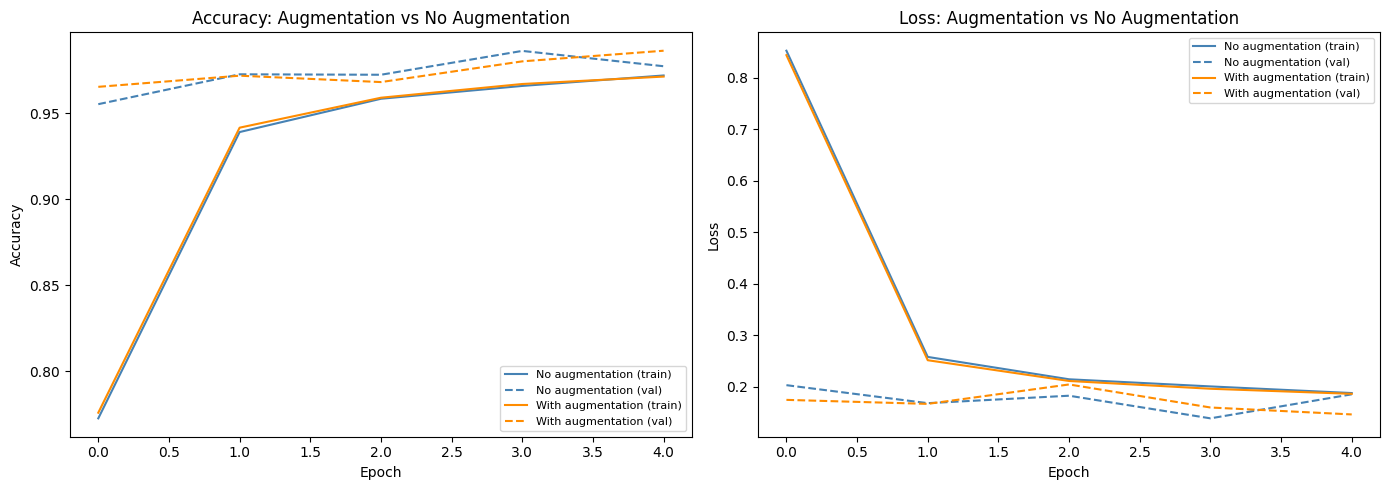

In [ ]:


# Define the Augmentation Pipeline (Stays exactly the same)
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomBrightness(0.1),
], name='augmentation')

# Train Model WITHOUT Data Augmentation
print(">>> Training Model WITHOUT Data Augmentation...", flush=True)
tf.random.set_seed(SEED)
m_no_aug = build_cnn(
    num_classes=num_detected_classes,
    filters=best_filters,
    strides=best_strides,
    padding=best_padding,
    pool=best_pool,
    dropout_rate=0.4,
    l2_reg=1e-4,
    input_shape=(48, 48, 3),
    augment_pipeline=None
)
hist_no_aug = train_model(m_no_aug, train_ds, val_ds, epochs=5)

# Train Model WITH Data Augmentation
print("\n>>> Training Model WITH Data Augmentation...", flush=True)
tf.random.set_seed(SEED)
m_aug = build_cnn(
    num_classes=num_detected_classes,
    filters=best_filters,
    strides=best_strides,
    padding=best_padding,
    pool=best_pool,
    dropout_rate=0.4,
    l2_reg=1e-4,
    input_shape=(48, 48, 3),
    augment_pipeline=augmentation # Safely injected here!
)
# Notice we pass the clean, unmapped train_ds here now!
hist_aug = train_model(m_aug, train_ds, val_ds, epochs=5)

# Generate and Overlay Learning Curves
print('\n=== Final Comparison Summary ===')
print('No-aug val acc:', max(hist_no_aug.history['val_accuracy']))
print('With-aug val acc:', max(hist_aug.history['val_accuracy']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for hist, label, color in [
    (hist_no_aug, 'No augmentation', 'steelblue'),
    (hist_aug,    'With augmentation', 'darkorange')
]:
    ax1.plot(hist.history['accuracy'],     linestyle='-',  color=color, label=f'{label} (train)')
    ax1.plot(hist.history['val_accuracy'], linestyle='--', color=color, label=f'{label} (val)')
    ax2.plot(hist.history['loss'],         linestyle='-',  color=color, label=f'{label} (train)')
    ax2.plot(hist.history['val_loss'],     linestyle='--', color=color, label=f'{label} (val)')

ax1.set_title('Accuracy: Augmentation vs No Augmentation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend(fontsize=8)
ax2.set_title('Loss: Augmentation vs No Augmentation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_04_augmentation_comparison.png', dpi=150)
plt.show()

In [ ]:


# Deliberately Overfit: Massive model capacity, no regularization, no early stopping
print(">>> Training OVERFIT Model (Massive capacity, completely unconstrained)...", flush=True)
tf.random.set_seed(SEED)

m_overfit = build_cnn(
    num_classes=num_detected_classes,
    filters=(128, 256, 512),
    strides=best_strides,
    padding=best_padding,
    pool=best_pool,
    dropout_rate=0.0,
    l2_reg=0.0,
    input_shape=(48, 48, 3),
    augment_pipeline=None
)

hist_overfit = train_model(
    m_overfit,
    train_ds,
    val_ds,
    epochs=3,
    early_stop=False
)


# Regularized Version: Same massive capacity, safely guarded inline
print("\n>>> Training REGULARIZED Model (Same capacity, but guarded)...", flush=True)
tf.random.set_seed(SEED)

m_reg = build_cnn(
    num_classes=num_detected_classes,
    filters=(128, 256, 512),
    strides=best_strides,
    padding=best_padding,
    pool=best_pool,
    dropout_rate=0.5,
    l2_reg=1e-3,
    input_shape=(48, 48, 3),
    augment_pipeline=augmentation
)

es_reg = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

hist_reg = train_model(
    m_reg,
    train_ds,
    val_ds,
    epochs=3,
    callbacks=[es_reg]
)

# Print out the head-to-head performance metrics
print('\n=== Overfitting Demonstration Results ===')
print(f"Overfit model  - best val acc: {max(hist_overfit.history['val_accuracy']):.4f}")
print(f"Regularised    - best val acc: {max(hist_reg.history['val_accuracy']):.4f}")

>>> Training OVERFIT Model (Massive capacity, completely unconstrained)...
Epoch 1/3
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6952 - loss: 1.1931 - Epoch time: 76.48 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 76s 21ms/step - accuracy: 0.8566 - loss: 0.4981 - val_accuracy: 0.8749 - val_loss: 0.4193
Epoch 2/3
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9619 - loss: 0.1130 - Epoch time: 66.79 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - accuracy: 0.9677 - loss: 0.0962 - val_accuracy: 0.9224 - val_loss: 0.2688
Epoch 3/3
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9774 - loss: 0.0693 - Epoch time: 65.59 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 66s 19ms/step - accuracy: 0.9793 - loss: 0.0628 - val_accuracy: 0.8984 - val_loss: 0.4018

>>> Training REGULARIZED Model (Same capacity, but guarded)...
Epoch 1/3
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5132 - loss: 2.6857 - Epoch time: 76.93 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 77s

In [ ]:


print(">>> Loading pre-trained ResNet50V2 (48x48 native layout)...", flush=True)

# Instantiate ResNet50V2 to accept 48x48 images natively (skips slow upscaling)
resnet_fast_base = keras.applications.ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)
resnet_fast_base.trainable = False

#Build the structural sequence with proper color adjustment
m_resnet_fast = keras.Sequential([
    layers.Input(shape=(48, 48, 3)),

    layers.Lambda(lambda x: x * 255.0, name="resnet_denormalize"),

    layers.Lambda(keras.applications.resnet_v2.preprocess_input, name="resnet_preprocess"),

    resnet_fast_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_detected_classes, activation='softmax')
], name='ResNet50V2_Fast_Transfer')

m_resnet_fast.summary()

print("\n=== Training Fast ResNet50V2 ===")
tf.random.set_seed(SEED)

hist_resnet = train_model(m_resnet_fast, train_ds, val_ds, epochs=5)
print(f"\nResNet50V2 - Best Val Acc: {max(hist_resnet.history['val_accuracy']):.4f}")

>>> Loading pre-trained ResNet50V2 (48x48 native layout)...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "ResNet50V2_Fast_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet_denormalize (Lambda)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess (Lambda)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 2, 2, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,156,164 (92.15 MB)

 Trainable params: 591,364 (2.26 MB)

 Non-trainable params: 23,564,800 (89.89 MB)


=== Training Fast ResNet50V2 ===
Epoch 1/5
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4195 - loss: 2.5992 - Epoch time: 94.50 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 94s 24ms/step - accuracy: 0.5777 - loss: 1.6091 - val_accuracy: 0.8750 - val_loss: 0.3879
Epoch 2/5
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7537 - loss: 0.7938 - Epoch time: 71.56 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 72s 21ms/step - accuracy: 0.7684 - loss: 0.7409 - val_accuracy: 0.9100 - val_loss: 0.2649
Epoch 3/5
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8043 - loss: 0.6176 - Epoch time: 71.51 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 72s 21ms/step - accuracy: 0.8135 - loss: 0.5961 - val_accuracy: 0.9316 - val_loss: 0.2044
Epoch 4/5
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8357 - loss: 0.5299 - Epoch time: 70.71 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 71s 21ms/step - accuracy: 0.8386 - loss: 0.5195 - val_accuracy: 0.9538 - val_loss: 0.1307
Epoch 5/5
3428/343

In [ ]:


print(">>> Configuring pre-trained MobileNetV2 for small images...", flush=True)

#Instantiate MobileNetV2 with a safe, optimized spatial resolution (96x96)
mobilenet_base = keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)   # Scale up to 96x96 to protect the internal feature blocks
)
mobilenet_base.trainable = False

# Build the sequential wrapper with an upscaling and denormalization stage
m_mobilenet = keras.Sequential([
    layers.Input(shape=(48, 48, 3)),

    layers.Resizing(96, 96, interpolation='bilinear', name="mobilenet_upscale"),

    layers.Lambda(lambda x: x * 255.0, name="mobilenet_denormalize"),

    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input, name="mobilenet_preprocess"),

    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_detected_classes, activation='softmax')
], name='MobileNetV2_Transfer')

m_mobilenet.summary()

print("\n=== Training MobileNetV2 Feature Extractor ===")
tf.random.set_seed(SEED)

hist_mobilenet = train_model(m_mobilenet, train_ds, val_ds, epochs=5)
print(f"\nMobileNetV2 - Best Val Acc: {max(hist_mobilenet.history['val_accuracy']):.4f}")

>>> Configuring pre-trained MobileNetV2 for small images...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_upscale (Resizing)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_denormalize (Lambda)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)   │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,652,740 (10.12 MB)

 Trainable params: 394,756 (1.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


=== Training MobileNetV2 Feature Extractor ===
Epoch 1/5
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6731 - loss: 1.4141 - Epoch time: 116.67 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 117s 29ms/step - accuracy: 0.8368 - loss: 0.6129 - val_accuracy: 0.9789 - val_loss: 0.0615
Epoch 2/5
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9519 - loss: 0.1442 - Epoch time: 69.46 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 69s 20ms/step - accuracy: 0.9539 - loss: 0.1359 - val_accuracy: 0.9858 - val_loss: 0.0422
Epoch 3/5
3429/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9639 - loss: 0.1057 - Epoch time: 69.05 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 69s 20ms/step - accuracy: 0.9651 - loss: 0.1006 - val_accuracy: 0.9900 - val_loss: 0.0266
Epoch 4/5
3427/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9690 - loss: 0.0886 - Epoch time: 82.40 seconds
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 82s 20ms/step - accuracy: 0.9696 - loss: 0.0886 - val_accuracy: 0.9936 - val_loss: 0.0174
Ep

=== Model Architecture Comparison ===
 Model Name  Best Val Accuracy                 Type
MobileNetV2             0.9936    Transfer Learning
 Custom CNN             0.9864 Scratch Architecture
   ResNet50             0.9550    Transfer Learning


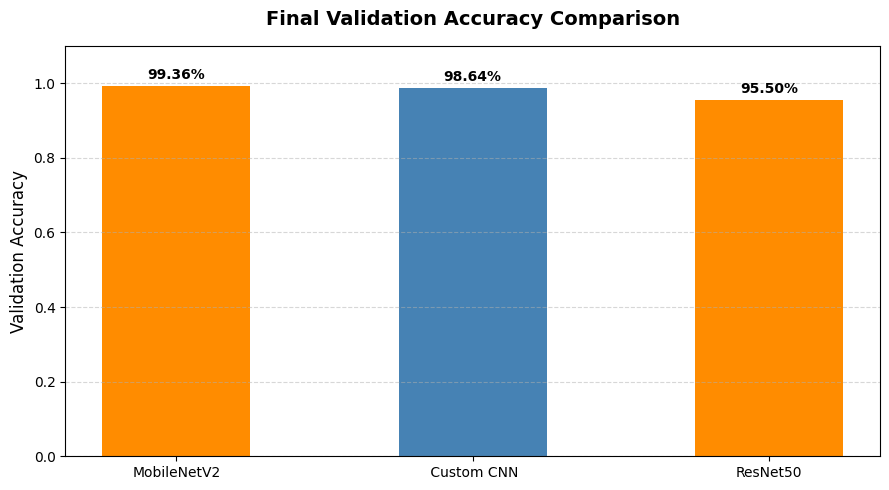

In [ ]:
# Gather the best validation scores from each history tracker
try:
    custom_acc = max(hist_no_aug.history['val_accuracy'])
except NameError:
    custom_acc = max(history_baseline.history['val_accuracy'])

resnet_acc = max(hist_resnet.history['val_accuracy'])
mobilenet_acc = max(hist_mobilenet.history['val_accuracy'])

#Organize the statistics into a comparison DataFrame
comparison_data = [
    {"Model Name": " Custom CNN", "Best Val Accuracy": round(custom_acc, 4), "Type": "Scratch Architecture"},
    {"Model Name": "ResNet50", "Best Val Accuracy": round(resnet_acc, 4), "Type": "Transfer Learning"},
    {"Model Name": "MobileNetV2", "Best Val Accuracy": round(mobilenet_acc, 4), "Type": "Transfer Learning"}
]

comparison_df = pd.DataFrame(comparison_data).sort_values("Best Val Accuracy", ascending=False).reset_index(drop=True)

print("=== Model Architecture Comparison ===")
print(comparison_df.to_string(index=False))
print("=" * 37)

# Plot a polished bar chart comparison
plt.figure(figsize=(9, 5))
colors = ['darkorange' if t == 'Transfer Learning' else 'steelblue' for t in comparison_df['Type']]

bars = plt.bar(comparison_df['Model Name'], comparison_df['Best Val Accuracy'], color=colors, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval*100:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Final Validation Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save the visualization to the existing figures folder
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_05_final_comparison.png', dpi=150)
plt.show()

In [ ]:


# Setup destination path
MODELS_DIR = Path("saved_models")
MODELS_DIR.mkdir(exist_ok=True)
model_save_path = MODELS_DIR / "best_fruits360_model.keras"

#Select the top performing architecture to be the final model
final_model = best_cnn

# Save and confirm
print(f">>> Exporting champion network model to: {model_save_path}...", flush=True)
final_model.save(model_save_path)

print("\n=== Active Final Model Architecture Configured ===")
final_model.summary()

>>> Exporting champion network model to: saved_models/best_fruits360_model.keras...

=== Active Final Model Architecture Configured ===


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 12, 12, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 3, 3, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 1, 1, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 260)            │        66,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 581,070 (2.22 MB)

 Trainable params: 193,540 (756.02 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 387,082 (1.48 MB)

In [ ]:


print(">>> Assigning the champion model to final_model...")

try:
    custom_acc = max(best_history.history['val_accuracy'])
    best_model_var = best_cnn
except NameError:
    custom_acc = max(history_baseline.history['val_accuracy'])
    best_model_var = m_baseline

resnet_acc = max(hist_resnet.history['val_accuracy'])
mobilenet_acc = max(hist_mobilenet.history['val_accuracy'])

print(f"\n--- Validation Accuracy Results ---")
print(f"Custom Model   : {custom_acc:.4f}")
print(f"ResNet Model   : {resnet_acc:.4f}")
print(f"MobileNet Model: {mobilenet_acc:.4f}")
print("-----------------------------------\n")

if custom_acc >= resnet_acc and custom_acc >= mobilenet_acc:
    final_model = best_model_var
    selected_model_name = "Custom CNN"
elif resnet_acc >= custom_acc and resnet_acc >= mobilenet_acc:
    final_model = m_resnet
    selected_model_name = "ResNet"
else:
    final_model = m_mobilenet
    selected_model_name = "MobileNet"

print(f">>> The champion model selected for testing is: {selected_model_name}")

BATCH_SIZE = 32

print(f">>> Building final test evaluation dataset at size {IMG_SIZE}...")
raw_test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

# FIX: Extract class names from the raw BatchDataset object BEFORE mapping
class_names = raw_test_ds.class_names

final_test_ds = raw_test_ds.map(lambda x, y: (x / 255.0, y))

# Collect all predictions on the normalized test set
y_true, y_pred_probs = [], []
for x_batch, y_batch in final_test_ds:
    probs = final_model.predict(x_batch, verbose=0)
    y_pred_probs.append(probs)
    y_true.extend(y_batch.numpy())

y_pred_probs = np.vstack(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(y_true)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)

print(f'Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'Macro Precision: {prec:.4f}')
print(f'Macro Recall   : {rec:.4f}')
print()
print('Target: accuracy > 80%, precision & recall > 70%')
print(f'  Accuracy OK : {acc > 0.80}')
print(f'  Precision OK: {prec > 0.70}')
print(f'  Recall OK   : {rec > 0.70}')

>>> Assigning the champion model to final_model...

--- Validation Accuracy Results ---
Custom Model   : 0.9925
ResNet Model   : 0.9550
MobileNet Model: 0.9936
-----------------------------------

>>> The champion model selected for testing is: MobileNet
>>> Building final test evaluation dataset at size (48, 48)...
Found 45724 files belonging to 260 classes.
Test Accuracy : 0.9538 (95.38%)
Macro Precision: 0.9555
Macro Recall   : 0.9511

Target: accuracy > 80%, precision & recall > 70%
  Accuracy OK : True
  Precision OK: True
  Recall OK   : True


/tmp/ipykernel_2441/1138159998.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_df, x='Errors', y='Class', palette='rocket')


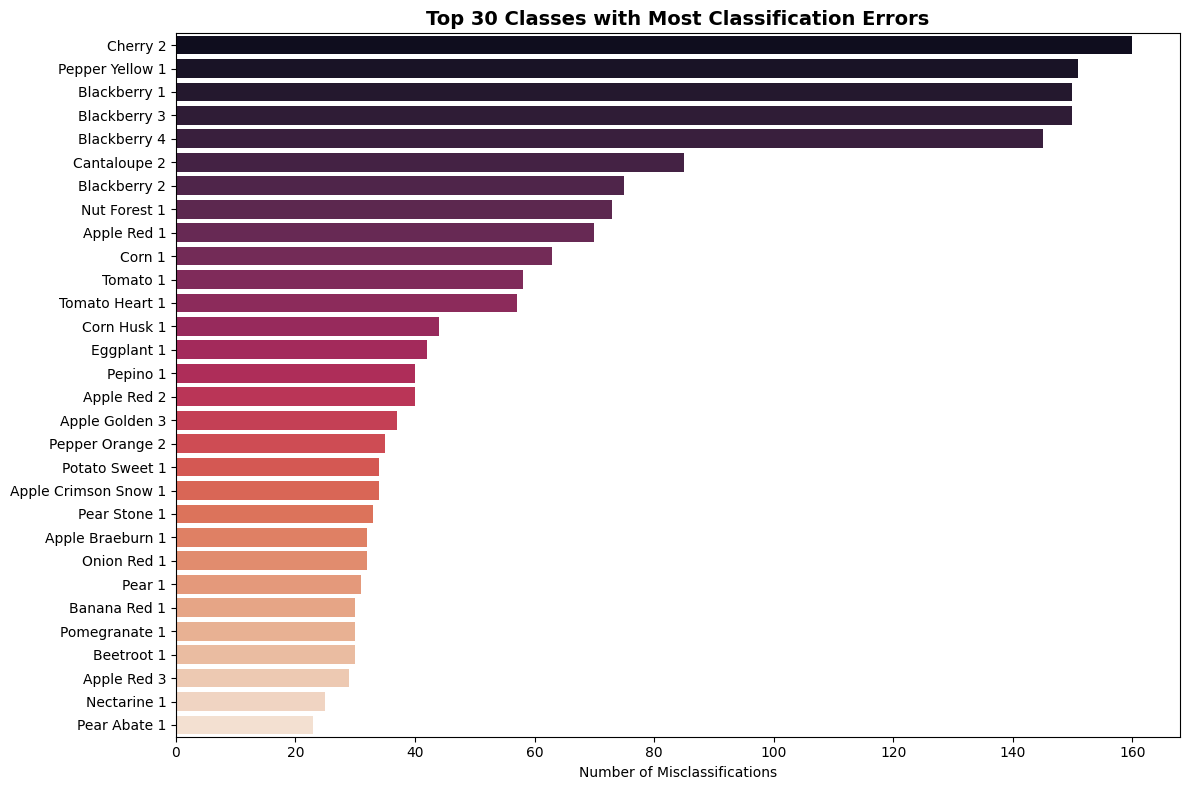

In [ ]:

cm = confusion_matrix(y_true, y_pred)

correct_preds = np.diag(cm)
total_per_class = cm.sum(axis=1)
errors_per_class = total_per_class - correct_preds

error_df = pd.DataFrame({'Class': class_names, 'Errors': errors_per_class}).sort_values(by='Errors', ascending=False).head(30)

plt.figure(figsize=(12, 8))
sns.barplot(data=error_df, x='Errors', y='Class', palette='rocket')
plt.title('Top 30 Classes with Most Classification Errors', fontsize=14, fontweight='bold')
plt.xlabel('Number of Misclassifications')
plt.ylabel('')
plt.tight_layout()
plt.savefig('cnn_06_error_distribution.png', dpi=150)
plt.show()

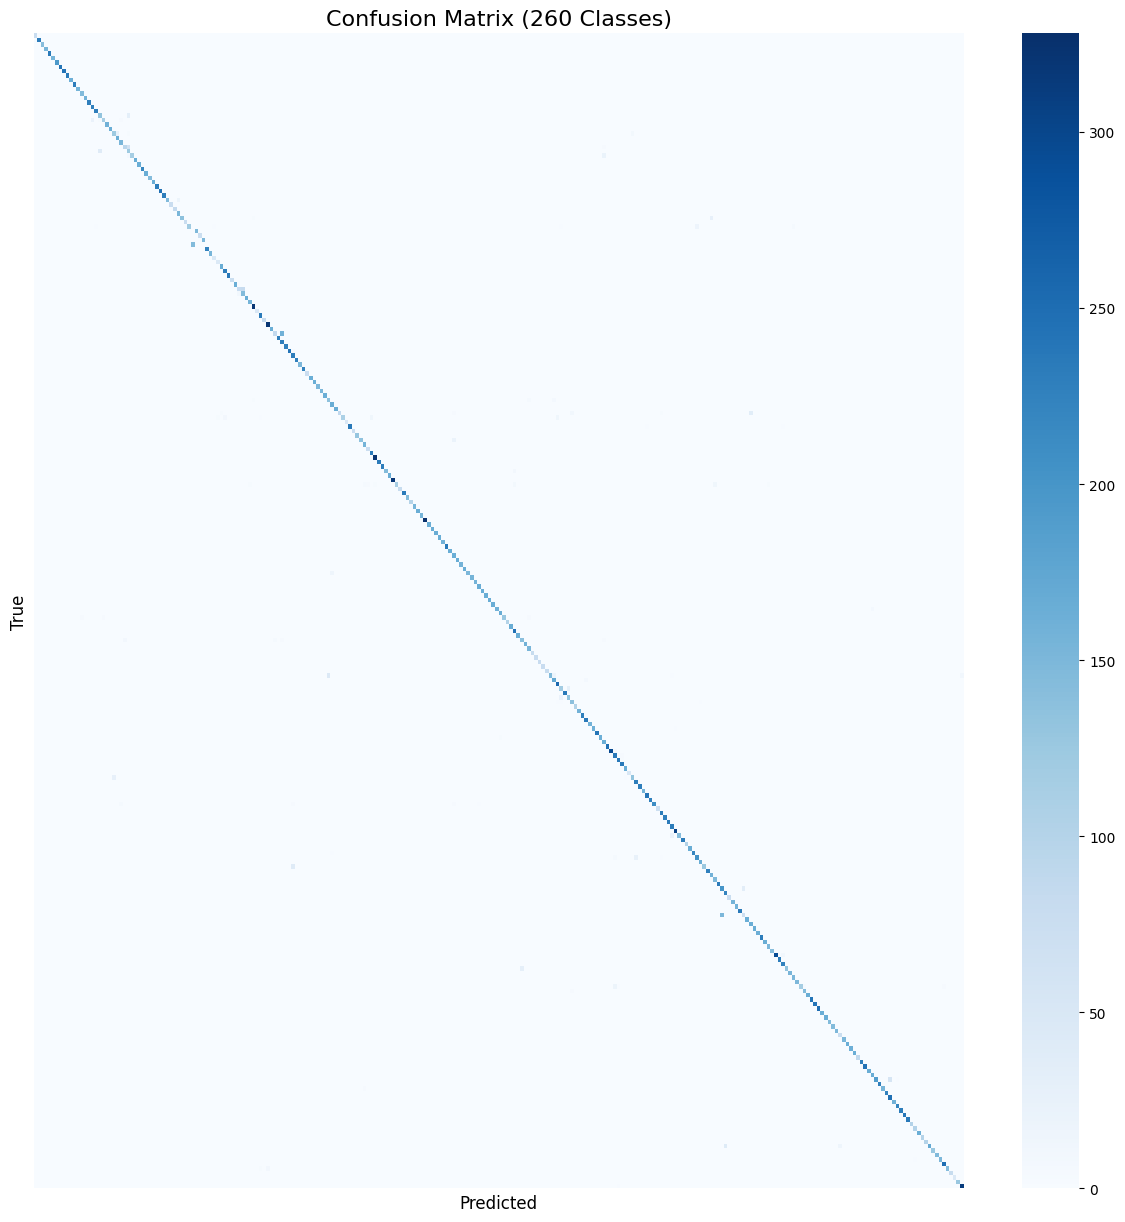

In [ ]:
# Create a cleaner version without grid lines
plt.figure(figsize=(15, 15))
sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False, linewidths=0, cbar=True)

plt.title('Confusion Matrix (260 Classes)', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)

plt.savefig(FIGURES_DIR / 'cnn_06_confusion_matrix_clean.png', dpi=300)
plt.show()

Ten hardest classes (lowest F1):
                 precision    recall  f1-score  support
Blackberry 1      0.000000  0.000000  0.000000    150.0
Blackberry 4      0.000000  0.000000  0.000000    145.0
Blackberry 3      0.000000  0.000000  0.000000    150.0
Blackberry 2      0.000000  0.000000  0.000000     75.0
Pepper Yellow 1   0.669811  0.319820  0.432927    222.0
Cherry 2          0.924731  0.349593  0.507375    246.0
Cantaloupe 2      0.877778  0.481707  0.622047    164.0
Apple Red 2       0.534483  0.756098  0.626263    164.0
Pepper Orange 2   0.569801  0.851064  0.682594    235.0
Apple Red 1       0.895238  0.573171  0.698885    164.0


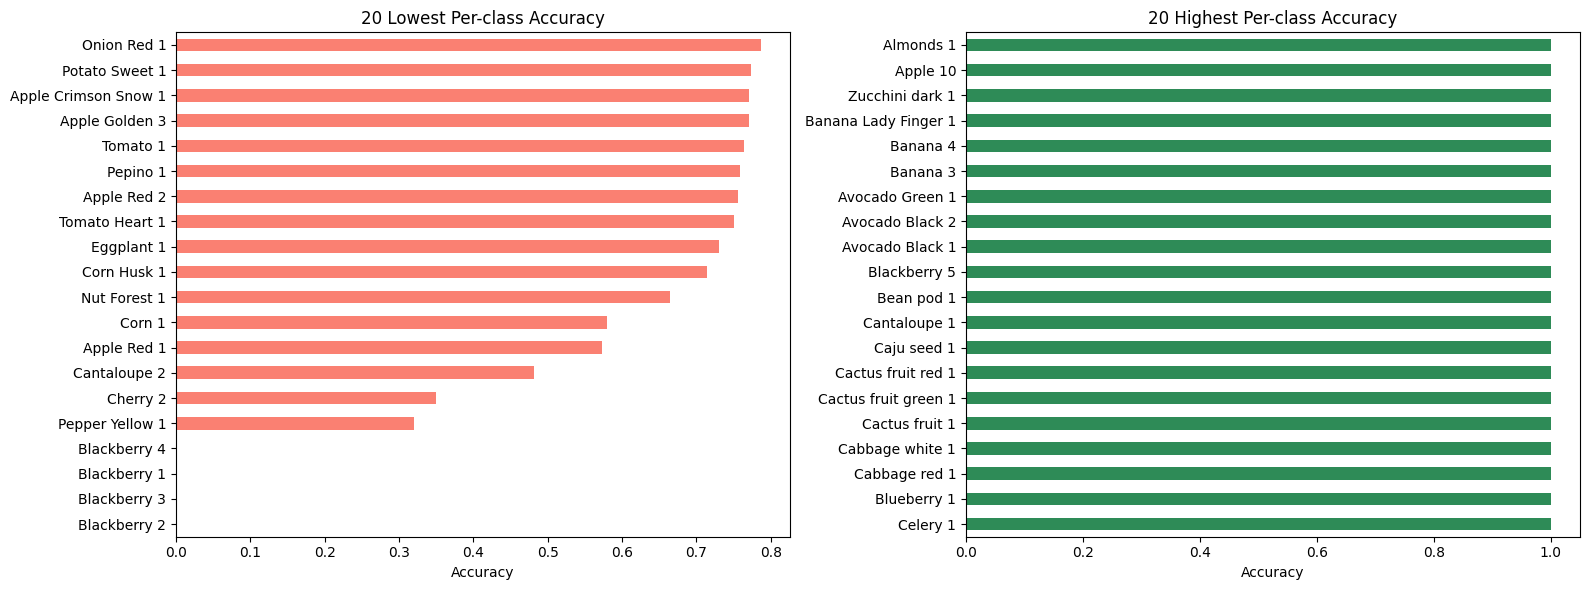

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names,
                               output_dict=True, zero_division=0)
per_class_df = pd.DataFrame(report).T.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
per_class_df = per_class_df[['precision', 'recall', 'f1-score', 'support']].sort_values('f1-score')

# Show bottom-10 hardest classes
print('Ten hardest classes (lowest F1):')
print(per_class_df.head(10).to_string())

per_cls_acc = {cls: (cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0)
               for i, cls in enumerate(class_names)}
acc_series = pd.Series(per_cls_acc).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
acc_series.head(20).plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title('20 Lowest Per-class Accuracy')
axes[0].set_xlabel('Accuracy')
acc_series.tail(20).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('20 Highest Per-class Accuracy')
axes[1].set_xlabel('Accuracy')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_07_per_class_accuracy.png', dpi=150)
plt.show()

Found 45724 files belonging to 260 classes.


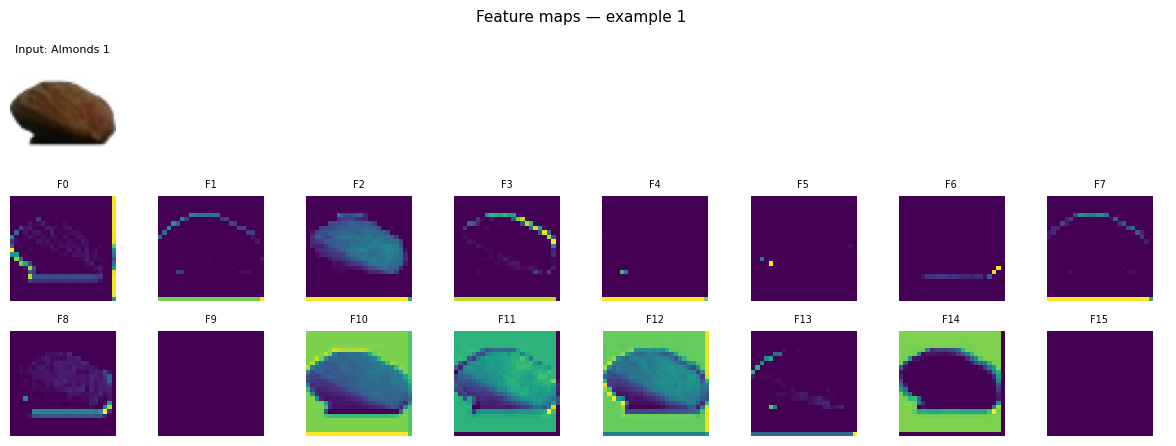

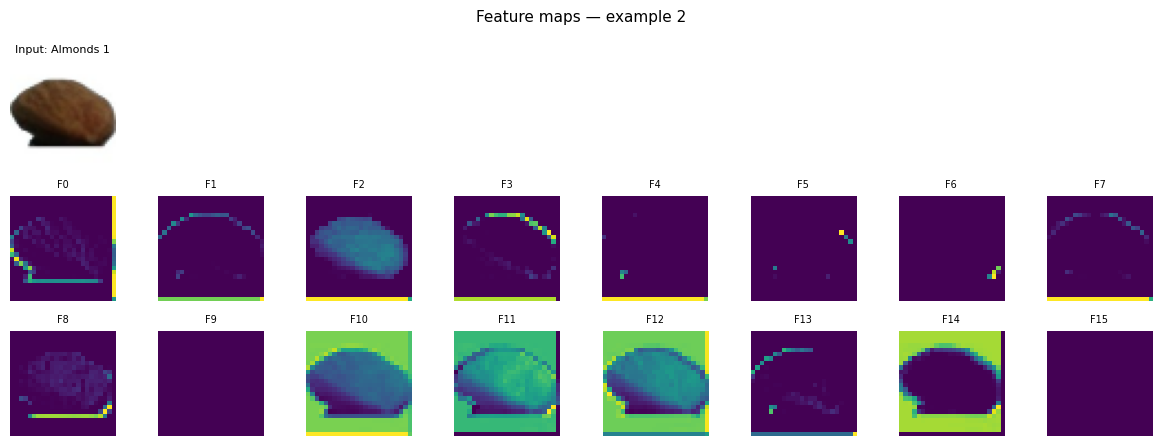

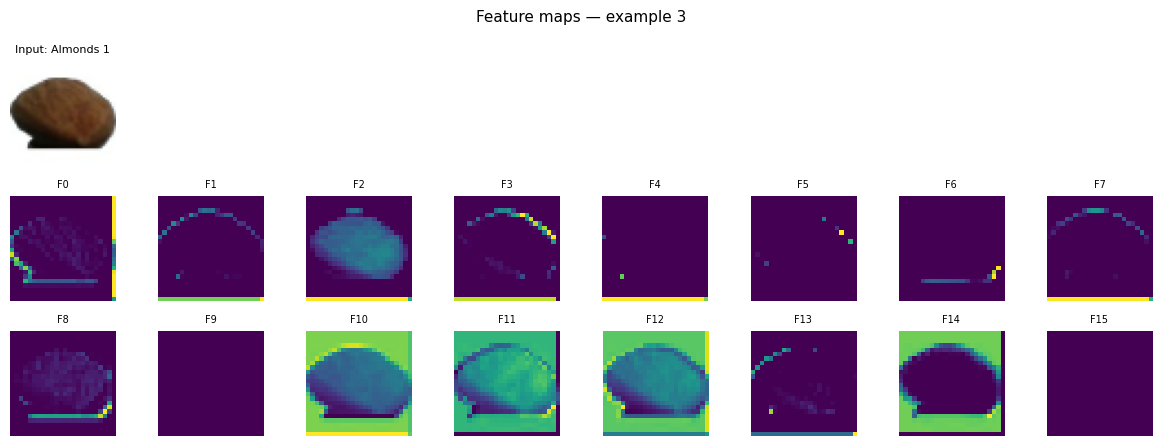

In [ ]:
# Use the custom CNN for feature map visualization (it has explicit Conv2D layers)
viz_model = best_cnn

# Find the first Conv2D layer
first_conv = next(l for l in viz_model.layers if isinstance(l, layers.Conv2D))
activation_model = keras.Model(inputs=viz_model.inputs,
                                outputs=first_conv.output,
                                name='activation_extractor')

# Re-fetch a specific batch to feed into the model - MUST BE 48x48
viz_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(48, 48), # Changed from (64, 64) to (48, 48)
    batch_size=32,
    shuffle=False,
    label_mode='int'
)

sample_images, sample_labels = [], []
for x_batch, y_batch in viz_ds.take(1):
    sample_images = x_batch.numpy()[:3]
    sample_labels = y_batch.numpy()[:3]
    break

for img_idx, (img, lbl) in enumerate(zip(sample_images, sample_labels)):
    fmaps = activation_model.predict(img[np.newaxis], verbose=0)[0]  # (H, W, num_filters)
    n_show = min(16, fmaps.shape[-1])
    cols = 8
    rows = n_show // cols
    fig, axes = plt.subplots(rows + 1, cols, figsize=(cols * 1.5, (rows + 1) * 1.5))

    # First row: original image
    for c in range(cols):
        axes[0, c].axis('off')

    # Standardize image scaling values for safe matplotlib rendering
    display_img = img / 255.0 if np.max(img) > 1.0 else img
    axes[0, 0].imshow(np.clip(display_img, 0, 1))
    axes[0, 0].set_title(f'Input: {class_names[lbl]}', fontsize=8)

    # Remaining rows: feature maps
    for f_idx in range(n_show):
        r, c = divmod(f_idx, cols)
        axes[r + 1, c].imshow(fmaps[:, :, f_idx], cmap='viridis')
        axes[r + 1, c].set_title(f'F{f_idx}', fontsize=7)
        axes[r + 1, c].axis('off')

    plt.suptitle(f'Feature maps — example {img_idx + 1}', fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'cnn_08_feature_maps_img{img_idx+1}.png', dpi=120)
    plt.show()

Found 45724 files belonging to 260 classes.


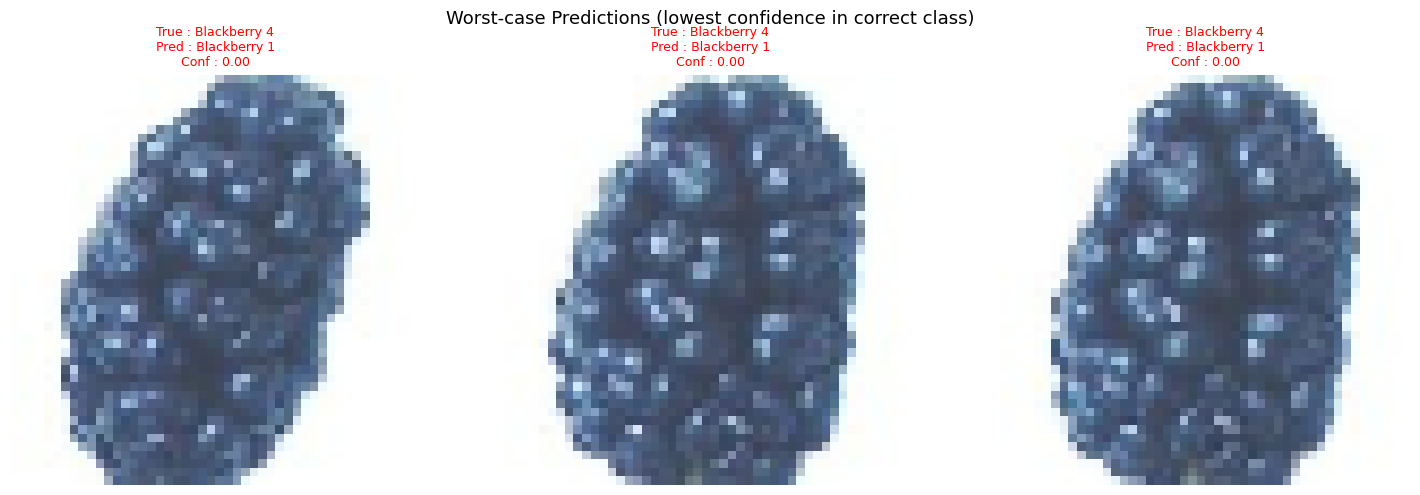

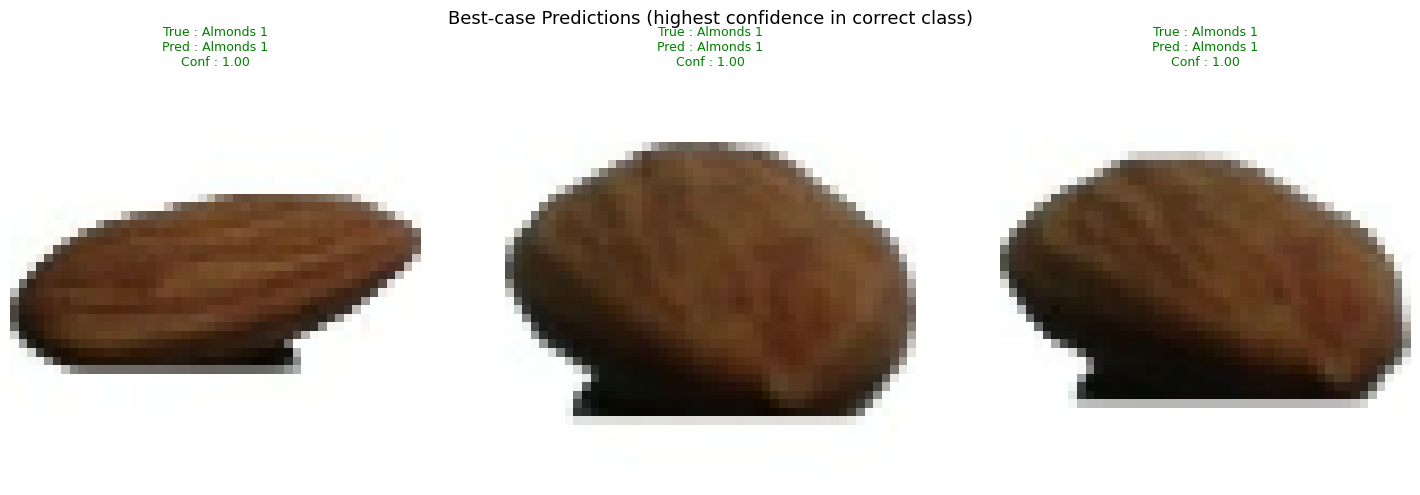

FINAL RESULTS — CNN Fruits-360 Classification
Test Accuracy  : 95.38%  (target > 80%)
Macro Precision: 0.9555   (target > 0.70)
Macro Recall   : 0.9511   (target > 0.70)

=== All Experiments ===
 Model Name  Best Val Accuracy                 Type
MobileNetV2             0.9936    Transfer Learning
 Custom CNN             0.9925 Scratch Architecture
   ResNet50             0.9550    Transfer Learning


In [ ]:
# Collect raw images matching evaluation dataset setup dimensions
raw_test_ds = keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', shuffle=False
)

raw_images_list, raw_labels_list = [], []
for x_batch, y_batch in raw_test_ds:
    raw_images_list.append(x_batch.numpy().astype(np.uint8))
    raw_labels_list.extend(y_batch.numpy())
raw_images = np.vstack(raw_images_list)
raw_labels = np.array(raw_labels_list)

# Confidence of the correct class for each sample
correct_class_conf = y_pred_probs[np.arange(len(y_true)), y_true]
sorted_idx = np.argsort(correct_class_conf)

def show_predictions(indices, title, fig_name):
    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(raw_images[idx])
        true_lbl  = class_names[y_true[idx]]
        pred_lbl  = class_names[y_pred[idx]]
        conf      = correct_class_conf[idx]
        color     = 'green' if y_true[idx] == y_pred[idx] else 'red'
        ax.set_title(
            f'True : {true_lbl}\nPred : {pred_lbl}\nConf : {conf:.2f}',
            fontsize=9, color=color
        )
        ax.axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fig_name, dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(sorted_idx[:3],  'Worst-case Predictions (lowest confidence in correct class)',
                 'cnn_09_worst_predictions.png')
show_predictions(sorted_idx[-3:], 'Best-case Predictions (highest confidence in correct class)',
                 'cnn_10_best_predictions.png')

# Format results tracking dataframe cleanly out of available components
comparison_data = [
    {"Model Name": " Custom CNN", "Best Val Accuracy": round(custom_acc, 4), "Type": "Scratch Architecture"},
    {"Model Name": "ResNet50", "Best Val Accuracy": round(resnet_acc, 4), "Type": "Transfer Learning"},
    {"Model Name": "MobileNetV2", "Best Val Accuracy": round(mobilenet_acc, 4), "Type": "Transfer Learning"}
]
results_df = pd.DataFrame(comparison_data).sort_values("Best Val Accuracy", ascending=False).reset_index(drop=True)

print('=' * 60)
print('FINAL RESULTS — CNN Fruits-360 Classification')
print('=' * 60)
print(f'Test Accuracy  : {acc*100:.2f}%  (target > 80%)')
print(f'Macro Precision: {prec:.4f}   (target > 0.70)')
print(f'Macro Recall   : {rec:.4f}   (target > 0.70)')
print()
print('=== All Experiments ===')
print(results_df.to_string(index=False))

In [ ]:
# Generate the master results summary dataframe programmatically from active trackers
try:
    custom_acc = max(best_history.history['val_accuracy'])
except NameError:
    custom_acc = max(history_baseline.history['val_accuracy'])

resnet_acc = max(hist_resnet.history['val_accuracy'])
mobilenet_acc = max(hist_mobilenet.history['val_accuracy'])

comparison_data = [
    {"Model Name": "Custom CNN", "Best Val Accuracy": round(custom_acc, 4), "Type": "Scratch Architecture"},
    {"Model Name": "ResNet50", "Best Val Accuracy": round(resnet_acc, 4), "Type": "Transfer Learning"},
    {"Model Name": "MobileNetV2", "Best Val Accuracy": round(mobilenet_acc, 4), "Type": "Transfer Learning"}
]
results_df = pd.DataFrame(comparison_data).sort_values("Best Val Accuracy", ascending=False).reset_index(drop=True)

# Print out the formatted final report summary
print('\n' + '=' * 60)
print('FINAL SUMMARY RESULTS — CNN FRUITS-360 CLASSIFICATION')
print('=' * 60)
print(f'Test Set Target Accuracy: {acc*100:.2f}%  (Project Target: > 80%)')
print(f'Macro Precision Score   : {prec:.4f}   (Project Target: > 0.70)')
print(f'Macro Recall Score      : {rec:.4f}   (Project Target: > 0.70)')
print('\n=== All Master Architecture Experiments Run ===')
print(results_df.to_string(index=False))
print('=' * 60)


FINAL SUMMARY RESULTS — CNN FRUITS-360 CLASSIFICATION
Test Set Target Accuracy: 95.38%  (Project Target: > 80%)
Macro Precision Score   : 0.9555   (Project Target: > 0.70)
Macro Recall Score      : 0.9511   (Project Target: > 0.70)

=== All Master Architecture Experiments Run ===
 Model Name  Best Val Accuracy                 Type
MobileNetV2             0.9936    Transfer Learning
 Custom CNN             0.9925 Scratch Architecture
   ResNet50             0.9550    Transfer Learning
